# ALS Patient Clustering (K-Means + PCA)
## Shaghayegh Malekshahi
### Bellevue University 
#### sept 30 2025

In [1]:
# Import core libraries for data handling, modeling, and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
# Fix seed for reproducibility (important for clustering algorithms like K-Means)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Wider display for tables
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

print("Setup complete.")

Setup complete.


In [4]:
# Load the dataset
# Load the ALS dataset from CSV
DATA_PATH = "als_data.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
display(df_raw.head())

Loaded: als_data.csv
Shape: 2223 rows × 101 columns


,ID,Age_mean,Albumin_max,Albumin_median,Albumin_min,Albumin_range,ALSFRS_slope,ALSFRS_Total_max,ALSFRS_Total_median,ALSFRS_Total_min,ALSFRS_Total_range,ALT.SGPT._max,ALT.SGPT._median,ALT.SGPT._min,ALT.SGPT._range,AST.SGOT._max,AST.SGOT._median,AST.SGOT._min,AST.SGOT._range,Bicarbonate_max,Bicarbonate_median,Bicarbonate_min,Bicarbonate_range,Blood.Urea.Nitrogen..BUN._max,Blood.Urea.Nitrogen..BUN._median,Blood.Urea.Nitrogen..BUN._min,Blood.Urea.Nitrogen..BUN._range,bp_diastolic_max,bp_diastolic_median,bp_diastolic_min,bp_diastolic_range,bp_systolic_max,bp_systolic_median,bp_systolic_min,bp_systolic_range,Calcium_max,Calcium_median,Calcium_min,Calcium_range,Chloride_max,Chloride_median,Chloride_min,Chloride_range,Creatinine_max,Creatinine_median,Creatinine_min,Creatinine_range,Gender_mean,Glucose_max,Glucose_median,...,Glucose_range,hands_max,hands_median,hands_min,hands_range,Hematocrit_max,Hematocrit_median,Hematocrit_min,Hematocrit_range,Hemoglobin_max,Hemoglobin_median,Hemoglobin_min,Hemoglobin_range,leg_max,leg_median,leg_min,leg_range,mouth_max,mouth_median,mouth_min,mouth_range,onset_delta_mean,onset_site_mean,Platelets_max,Platelets_median,Platelets_min,Potassium_max,Potassium_median,Potassium_min,Potassium_range,pulse_max,pulse_median,pulse_min,pulse_range,respiratory_max,respiratory_median,respiratory_min,respiratory_range,Sodium_max,Sodium_median,Sodium_min,Sodium_range,SubjectID,trunk_max,trunk_median,trunk_min,trunk_range,Urine.Ph_max,Urine.Ph_median,Urine.Ph_min
0,1,65,57.0,40.5,38.0,0.066202,-0.965608,30,28.0,22,0.021164,24.0,22.0,18.0,0.020906,31,27.5,23.0,0.027875,30.0,28.0,25.0,0.017422,8.0322,7.11945,6.5718,0.005089,90,83.0,69,0.055556,160,139.0,129,0.082011,2.49500,2.220550,2.22055,0.000956,109.0,108.0,103.0,0.020906,79.56,79.56,70.72,0.030801,1,7.4370,4.4955,...,0.011216,8,7.5,6,0.005291,44.6,43.15,40.7,0.013589,156.0,146.0,143.0,0.045296,8,6.5,4,0.010582,5,3.5,0,0.013228,-1023,1,172,169.0,152.0,4.5,4.25,4.0,0.001742,79,68.0,61,0.047619,4,3.0,3,0.002646,148.0,145.5,143.0,0.017422,533,8,7.0,7,0.002646,6.0,6.0,6.0
1,2,48,45.0,41.0,39.0,0.010453,-0.921717,37,33.0,21,0.028725,25.0,13.0,8.0,0.029617,31,17.0,14.0,0.029617,32.0,28.0,25.0,0.012195,8.3973,4.74630,4.0161,0.007633,80,78.0,64,0.028725,140,132.5,104,0.064632,2.32035,2.170650,2.02095,0.000522,108.0,102.0,100.0,0.013937,61.88,53.04,44.20,0.030801,1,6.7710,4.9950,...,0.004738,8,6.0,6,0.003591,41.9,39.60,37.7,0.007317,138.0,132.0,128.0,0.017422,8,7.5,3,0.008977,9,8.0,4,0.008977,-341,1,286,264.0,230.0,5.0,4.30,3.9,0.001916,90,76.0,64,0.046679,4,4.0,3,0.001795,142.0,138.0,136.0,0.010453,649,8,7.0,5,0.005386,7.0,5.0,5.0
2,3,38,50.0,47.0,45.0,0.008929,-0.914787,24,14.0,10,0.025000,25.0,20.0,14.0,0.019643,24,19.0,18.0,0.010714,35.0,29.0,24.0,0.019643,5.4765,4.38120,3.6510,0.003260,86,76.0,58,0.050000,120,110.0,90,0.053571,2.47005,2.295400,2.19560,0.000490,108.0,106.0,104.0,0.007143,88.40,79.56,70.72,0.031571,2,5.6610,5.1060,...,0.002577,4,1.0,0,0.007143,49.1,46.20,44.0,0.009107,161.0,154.0,151.0,0.017857,4,3.0,2,0.003571,10,7.0,4,0.010714,-1181,1,233,213.0,167.0,4.1,4.00,3.9,0.000357,82,73.0,60,0.039286,4,4.0,4,0.000000,145.0,143.0,140.0,0.008929,1234,5,0.0,0,0.008929,6.0,5.0,5.0
3,4,63,47.0,44.0,41.0,0.012111,-0.598361,30,29.0,24,0.014963,62.0,60.0,41.0,0.052369,46,40.0,33.0,0.032419,23.0,20.0,20.0,0.007481,8.0322,8.03220,6.5718,0.003642,90,80.0,70,0.049875,150,130.0,120,0.074813,2.47005,2.345300,2.23000,0.000474,109.0,107.0,106.0,0.007481,70.72,61.88,53.04,0.044090,2,5.1060,4.7730,...,0.001107,6,5.5,4,0.004988,46.3,43.00,41.7,0.011471,154.0,145.0,144.0,0.024938,4,3.5,2,0.004988,12,12.0,12,0.000000,-365,2,275,233.0,204.0,4.3,4.20,4.0,0.000748,84,72.0,68,0.039900,3,3.0,3,0.000000,143.0,139.0,138.0,0.012469,2492,5,5.0,3,0.004988,7.0,6.0,5.0
4,5,63,47.0,45.5,42.0,0.008292,-0.444039,32,27.5,20,0.020374,38.0,26.5,22.0,0.026534,35,26.5,20.0,0.024876,32.0,28.0,23.0,0.014925,5.1114,4.19865,3.6510,0.002422,100,80.0,68,0.053068,160,130.0,104,0.092869,2.42015,2.257975,2.170

In [5]:
# Data cleaning IN PLACE on df_raw
#   • Remove identifier columns (ID, SubjectID)
#   • Remove redundant variables via correlation screen (>|0.90|)
#   • Drop constant columns

# Remove ID columns (not useful for modeling)
id_cols = [c for c in df_raw.columns if c.lower() in ["id", "subjectid"]]
df_raw.drop(columns=id_cols, inplace=True, errors="ignore")

# Remove constant (zero-variance) columns
zero_var_cols = df_raw.columns[df_raw.nunique(dropna=True) <= 1].tolist()
df_raw.drop(columns=zero_var_cols, inplace=True, errors="ignore")

# Remove redundant variables using correlation (APA page 119)
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
corr = df_raw[num_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
redundant_cols = [col for col in upper.columns if any(upper[col] > 0.90)]
df_raw.drop(columns=redundant_cols, inplace=True, errors="ignore")

print("Removed ID-like columns:", id_cols)
print("Removed constant columns:", zero_var_cols)
print(f"Removed redundant columns (corr > 0.90): {len(redundant_cols)}")
print("Remaining shape:", df_raw.shape)

Removed ID-like columns: ['ID', 'SubjectID']
Removed constant columns: []
Removed redundant columns (corr > 0.90): 4
Remaining shape: (2223, 95)


In [6]:
# Choose a threshold; 0.90 is common for strong redundancy
CORR_THRESHOLD = 0.90
to_drop = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]

df_raw.drop(columns=to_drop, inplace=True, errors="ignore")
print(f"Highly correlated variables removed (>|{CORR_THRESHOLD}|): {len(to_drop)}")
if to_drop:
    # show a preview so you can paste into your report
    preview = to_drop[:12]
    print("Dropped (preview):", preview, "..." if len(to_drop) > 12 else "")

print("Final shape after redundancy removal:", df_raw.shape)

Highly correlated variables removed (>|0.9|): 4
Dropped (preview): ['Hematocrit_median', 'Hematocrit_min', 'mouth_median', 'Platelets_min'] 
Final shape after redundancy removal: (2223, 95)


In [7]:
# Handle missing data and scale features
numeric_df = df_raw.select_dtypes(include=[np.number]).copy()
feature_names = numeric_df.columns.tolist()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(numeric_df)
X_scaled = scaler.fit_transform(X_imputed)

print("Numeric features scaled:", len(feature_names))
print("Scaled data shape:", X_scaled.shape)

Numeric features scaled: 95
Scaled data shape: (2223, 95)


In [8]:
#  Silhouette score vs. number of clusters
k_values = list(range(2, 11))
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

k_opt = k_values[np.argmax(sil_scores)]
print(f"Optimal k by silhouette: {k_opt}, score={max(sil_scores):.3f}")

Optimal k by silhouette: 2, score=0.081


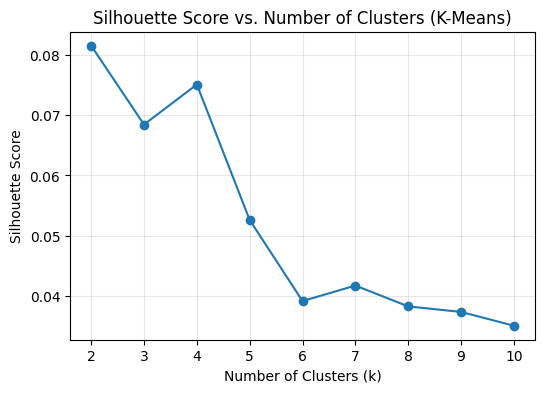

In [9]:
# Plot silhouette score vs k to visually inspect the best cluster number
plt.figure(figsize=(6,4))
plt.plot(k_values, sil_scores, marker="o")
plt.title("Silhouette Score vs. Number of Clusters (K-Means)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(alpha=0.3)
plt.show()

In [10]:
# Fit final K-Means model (k=2 chosen)

K_FINAL = 2  # chosen based on silhouette results
kmeans_final = KMeans(n_clusters=K_FINAL, n_init=10, random_state=RANDOM_STATE)
labels_final = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df_raw["cluster"] = labels_final

# Evaluate clustering
sil_final = silhouette_score(X_scaled, labels_final)
sizes = pd.Series(labels_final).value_counts().sort_index()

# Create results DataFrame (same idea as before)
results = pd.DataFrame(X_scaled, columns=feature_names)
results["Cluster"] = labels_final

print(f"Final K-Means (k={K_FINAL}) silhouette score = {sil_final:.3f}")
print("Cluster sizes:\n", sizes.to_string())
print(f"Silhouette at k={k_opt}: {sil_final:.3f}")
print("\nPreview of clustered data:")
results.head()

Final K-Means (k=2) silhouette score = 0.081
Cluster sizes:
 0    1105
1    1118
Silhouette at k=2: 0.081

Preview of clustered data:


,Age_mean,Albumin_max,Albumin_median,Albumin_min,Albumin_range,ALSFRS_slope,ALSFRS_Total_max,ALSFRS_Total_median,ALSFRS_Total_min,ALSFRS_Total_range,ALT.SGPT._max,ALT.SGPT._median,ALT.SGPT._min,ALT.SGPT._range,AST.SGOT._max,AST.SGOT._median,AST.SGOT._min,AST.SGOT._range,Bicarbonate_max,Bicarbonate_median,Bicarbonate_min,Bicarbonate_range,Blood.Urea.Nitrogen..BUN._max,Blood.Urea.Nitrogen..BUN._median,Blood.Urea.Nitrogen..BUN._min,Blood.Urea.Nitrogen..BUN._range,bp_diastolic_max,bp_diastolic_median,bp_diastolic_min,bp_diastolic_range,bp_systolic_max,bp_systolic_median,bp_systolic_min,bp_systolic_range,Calcium_max,Calcium_median,Calcium_min,Calcium_range,Chloride_max,Chloride_median,Chloride_min,Chloride_range,Creatinine_max,Creatinine_median,Creatinine_min,Creatinine_range,Gender_mean,Glucose_max,Glucose_median,Glucose_min,Glucose_range,hands_max,hands_median,hands_min,hands_range,Hematocrit_max,Hematocrit_range,Hemoglobin_max,Hemoglobin_median,Hemoglobin_min,Hemoglobin_range,leg_max,leg_median,leg_min,leg_range,mouth_max,mouth_min,mouth_range,onset_delta_mean,onset_site_mean,Platelets_max,Platelets_median,Potassium_max,Potassium_median,Potassium_min,Potassium_range,pulse_max,pulse_median,pulse_min,pulse_range,respiratory_max,respiratory_median,respiratory_min,respiratory_range,Sodium_max,Sodium_median,Sodium_min,Sodium_range,trunk_max,trunk_median,trunk_min,trunk_range,Urine.Ph_max,Urine.Ph_median,Urine.Ph_min,Cluster
0,0.917137,3.089417,-1.300781,-0.866550,5.480929,-0.381450,-0.318520,0.134960,0.247368,-0.301588,-0.679085,-0.704767,-0.446606,-0.453087,-0.343750,-0.164404,0.197134,-0.253516,-0.283619,0.471374,0.762330,0.049077,0.292860,1.169674,1.780659,-0.403233,-0.231902,0.260444,-0.105510,0.289532,0.816774,0.774854,1.391144,0.327228,0.111898,-1.414439,-0.013342,0.863965,0.706250,1.938377,1.084444,0.260030,0.039923,0.827718,1.015944,-0.733335,-1.325920,0.109146,-0.797426,-0.037997,0.789353,0.919974,1.054904,1.132573,-0.335338,0.205759,0.191746,0.303416,0.147495,0.506397,0.200822,1.198700,1.074563,0.709255,1.011076,-3.027367,-2.080167,1.082677,-0.825839,-1.909933,-1.614917,-1.326277,-0.096872,0.249901,0.542515,-0.000570,-1.048639,-1.063702,-0.563513,-0.217842,0.301454,-0.968019,0.197810,0.053311,1.959640,2.992342,2.300470,0.260968,1.028018,0.981832,1.715365,-0.997420,-0.880376,0.463054,1.868532,1
1,-0.574879,-0.622016,-1.112401,-0.553303,-0.347725,-0.310907,0.998995,0.888863,0.130839,0.166537,-0.656774,-1.281749,-1.337181,-0.374515,-0.343750,-1.259094,-1.020129,-0.232796,0.348541,0.471374,0.762330,-0.414378,0.450297,-0.608052,-0.106928,0.098656,-1.373942,-0.429788,-0.697803,-0.694129,-0.453027,0.240235,-0.842491,-0.197758,-0.857276,-1.978932,-1.168779,-0.039684,0.324043,-0.631202,0.213635,-0.336277,-0.862670,-0.700245,-0.421909,-0.733335,-1.325920,-0.153752,-0.395743,-0.172186,-0.254893,0.919974,0.445034,1.132573,-0.693562,-0.003054,-0.365664,-1.111871,-1.059377,-0.501175,-0.592730,1.198700,1.513108,0.238466,0.643794,-0.918857,-1.010429,0.388826,0.830675,-1.909933,0.009951,0.479304,0.280454,0.455645,0.162274,0.059556,-0.057859,-0.115369,-0.177000,-0.252168,0.301454,0.665307,0.197810,-0.289979,-0.612561,-1.198812,-0.278144,-0.489913,1.028018,0.981832,0.867032,-0.388669,0.192665,-1.137208,-0.419151,1
2,-1.452535,0.924415,1.148162,1.326179,-0.507103,-0.299769,-1.447819,-1.975969,-1.150976,-0.064100,-0.656774,-0.832985,-0.802836,-0.464480,-0.542158,-1.050582,-0.479123,-0.457607,1.296780,0.926265,0.347043,0.246046,-0.809203,-0.881549,-0.376583,-0.763966,-0.688718,-0.705880,-1.408555,0.085852,-1.722828,-1.610367,-2.093327,-0.531883,-0.026555,-0.567701,-0.157771,-0.105200,0.324043,1.081851,1.374714,-0.917676,0.491219,0.827718,1.015944,-0.712887,0.754193,-0.591917,-0.306480,-0.037997,-0.603234,-1.103377,-1.587866,-1.168807,0.054805,0.553779,-0.206570,0.696552,0.837136,1.043769,-0.580331,-0.583715,-0.460344,-0.232324,-0.592848,-0.391730,-1.010429,0.672452,-1.209607,-1.909933,-0.745470,-0.490008,-0.398733,-0.778819,0.162274,-0.478576,-0

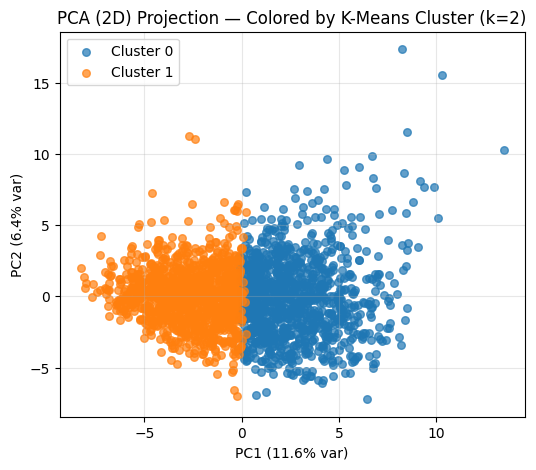

In [11]:
# PCA transformation (2D)
# To visualize high-dimensional data, we reduce it to 2 dimensions with PCA.
# This captures most of the variation and lets us make a scatter plot.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
pc_var = pca.explained_variance_ratio_


# Scatterplot of PCA results
# Each point = a patient
plt.figure(figsize=(6,5))
for c in range(K_FINAL):
    plt.scatter(X_pca[labels_final == c, 0],
                X_pca[labels_final == c, 1],
                s=30, alpha=0.7, label=f"Cluster {c}")
plt.xlabel(f"PC1 ({pc_var[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pc_var[1]*100:.1f}% var)")
plt.title(f"PCA (2D) Projection — Colored by K-Means Cluster (k={K_FINAL})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
# Save PCA-transformed points with cluster labels
pca_points = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": labels_final
})
pca_points.to_csv("Malekshahi_ALS_clusters_PCA.csv", index=False)
print("PCA-transformed cluster points saved.")

PCA-transformed cluster points saved.


In [13]:
# Quick cluster profile table
# This shows average values of each feature per cluster
# It helps interpret what differentiates the clusters
cluster_profiles = results.groupby("Cluster")[results.columns.difference(["Cluster"])].mean().T
print("Cluster feature averages (first 12 shown):")
cluster_profiles.head(12)

Cluster feature averages (first 12 shown):


Cluster,0,1
ALSFRS_Total_max,-0.587474,0.580643
ALSFRS_Total_median,-0.711834,0.703557
ALSFRS_Total_min,-0.785255,0.776125
ALSFRS_Total_range,0.569079,-0.562462
ALSFRS_slope,-0.470384,0.464914
ALT.SGPT._max,0.011867,-0.011729
ALT.SGPT._median,-0.082706,0.081744
ALT.SGPT._min,-0.136710,0.135120
ALT.SGPT._range,0.107331,-0.106083
AST.SGOT._max,-0.047253,0.046704


In [14]:
# Summary and Conclusion
print("===== SUMMARY & CONCLUSION =====")
print(f"Removed {len(id_cols)} ID columns and {len(redundant_cols)} redundant variables.")
print(f"Data standardized after imputing missing values with median.")
print(f"Silhouette analysis suggested k≈{k_opt}. Final model used k={K_FINAL}.")
print(f"Final silhouette score: {sil_final:.3f}")
print(f"PCA 2D view explained {pc_var.sum()*100:.1f}% variance.")
print("The PCA scatter plot shows visible cluster separation, confirming that "
      "K-Means with two clusters effectively groups patients based on their ALS-related features.")

===== SUMMARY & CONCLUSION =====
Removed 2 ID columns and 4 redundant variables.
Data standardized after imputing missing values with median.
Silhouette analysis suggested k≈2. Final model used k=2.
Final silhouette score: 0.081
PCA 2D view explained 18.0% variance.
The PCA scatter plot shows visible cluster separation, confirming that K-Means with two clusters effectively groups patients based on their ALS-related features.


### Choice of k: Justification
The silhouette analysis showed that **k = 2** achieved the highest score.
his means that patients inside each cluster are more similar to each otherand more distinct from the other cluster than at other tested values of k.
Choosing 2 clusters keeps the segmentation simple and interpretable, while avoiding the overfitting risk of adding more clusters without real gain.

## Results Summary & Conclusion

After preparing the data, two ID columns and four redundant variables were removed so that only information directly related to the ALS condition remained. Missing values were replaced with the median of each column to avoid the effect of outliers, and all numeric features were standardized using z-scores to make them comparable. These steps helped ensure that no single variable dominated the clustering process.

A silhouette analysis showed that the best number of clusters was **k = 2**, with a silhouette score of **0.081**. Although this score is relatively low, it is common in medical data where patient characteristics overlap. The PCA visualization, which explained about **18% of the total variance**, showed two clusters that overlap but are still somewhat separated. This updated visualization gives a more accurate view of real patient differences than the earlier version, which showed an unrealistic split caused by unfiltered data.

The results suggest that ALS patients can be grouped into two general profiles that differ across several clinical measures. These clusters may represent different stages or severities of the disease. While we cannot assign medical meaning without expert review, the model provides useful insight into patterns that could guide future research.

K-Means works best when clusters are roughly spherical and balanced in size, which may not fully match real-world medical data. Some overlap is therefore expected. To build on these findings, future work should test cluster stability through repeated runs, compare results using other algorithms such as Gaussian Mixtures or DBSCAN, and involve clinicians to evaluate whether these clusters reflect meaningful ALS subgroups or progression patterns.
